In [ ]:
# VS Code uses KaTeX, which cannot render R's LaTeX list environments.
# Keep HTML/text tables and image plots; apply again on every kernel restart.
options(jupyter.display_mimetypes = setdiff(
    getOption("jupyter.display_mimetypes", c("text/plain", "text/html", "text/markdown", "image/png", "image/jpeg", "image/svg+xml", "application/pdf")),
    "text/latex"
))

library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(RColorBrewer)
library(tibble)
library(harmony)


In [3]:
zemin <- readRDS("/Users/alex/Library/CloudStorage/OneDrive-Personal/A1_RioLab/01_Projects/02_Codes/1_CIVA/zemin_lung.rds")

In [4]:
zemin_short <- subset(
  x = zemin,
  subset = Final_annotation %in% c("MF-Monocytes", "tumor", "fibroblast", "endothelial")
)


In [5]:
zemin_short <- NormalizeData(zemin_short)
zemin_short <- FindVariableFeatures(zemin_short)
zemin_short <- ScaleData(zemin_short)
zemin_short <- RunPCA(zemin_short)
zemin_short <- FindNeighbors(zemin_short, dims = 1:30, reduction = "pca")
zemin_short <- FindClusters(zemin_short, resolution = 0.3)
zemin_short <- RunUMAP(zemin_short, dims = 1:30, reduction = "pca", reduction.name = "umap")

Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Centering and scaling data matrix

PC_ 1 
Positive:  DCN, CALD1, LUM, MGP, MFAP4, SPARCL1, THY1, RARRES2, FBLN1, COL1A1 
	   SERPINF1, TIMP3, TAGLN, LHFP, NNMT, CRISPLD2, TPM2, CTSK, PDGFRB, CCDC80 
	   PRELP, A2M, CD248, ACTA2, FN1, FSTL1, SOD3, OLFML3, SFRP2, PDLIM3 
Negative:  RSPH1, SNTN, C20orf85, C9orf24, FAM183A, TMEM190, MS4A8, FAM92B, LDLRAD1, CAPSL 
	   C1orf194, CAPS, ZMYND10, ROPN1L, C11orf88, PIFO, MORN5, CCDC78, C5orf49,

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12160
Number of edges: 433804

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9535
Number of communities: 17
Elapsed time: 1 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
21:04:56 UMAP embedding parameters a = 0.9922 b = 1.112

21:04:56 Read 12160 rows and found 30 numeric columns

21:04:56 Using Annoy for neighbor search, n_neighbors = 30

21:04:56 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:04:58 Writing NN index file to temp file /var/folders/4t/rg4j3ld147l36_20wbl0wjxh0000gn/T//RtmpCHxCcu/filed09f6e2a26b2

21:04:58 Searching Annoy index using 1 thread, search_k = 3000

21:05:01 Annoy recall = 100%

21:05:02 Commencing smooth kNN distance calibra

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


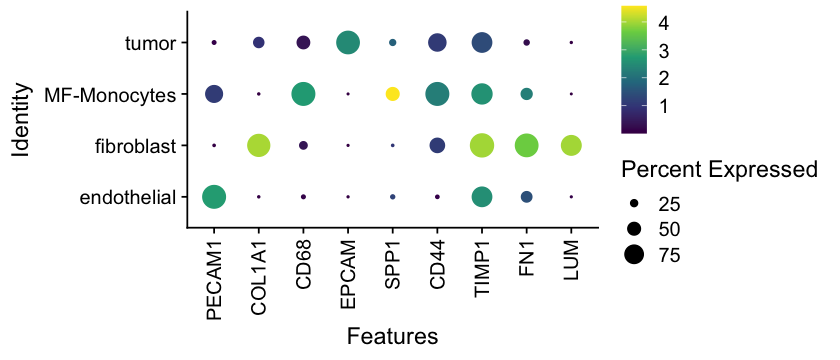

In [6]:
options(repr.plot.width = 7, repr.plot.height = 3)
library(RColorBrewer)

DotPlot(
  zemin_short,
  features = c('PECAM1','COL1A1','CD68','EPCAM',
               'SPP1','CD44','TIMP1','FN1','LUM'),
  group.by = 'Final_annotation',
  scale = FALSE
) +
  scale_colour_viridis_c(option = "viridis") +   # "viridis","plasma","inferno","cividis","turbo", etc.
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))


In [7]:
# Create a general cell type annotation column

In [8]:
all <- readRDS("/Users/alex/Library/CloudStorage/OneDrive-Personal/A1_RioLab/01_Projects/02_Codes/1_CIVA/Flex.rds")

In [9]:
all.monoMac <- subset(
  all,
  cells = rownames(all@meta.data)[grepl("Mac", all@meta.data$cell_type)]
)


In [10]:
all.monoMac <- NormalizeData(all.monoMac)
all.monoMac <- FindVariableFeatures(all.monoMac)
all.monoMac <- ScaleData(all.monoMac)
all.monoMac <- RunPCA(all.monoMac)
all.monoMac <- FindNeighbors(all.monoMac, dims = 1:50, reduction = "pca")
all.monoMac <- FindClusters(all.monoMac, resolution = 0.5)
all.monoMac <- RunUMAP(all.monoMac, dims = 1:50, reduction = "pca", reduction.name = "umap")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  MKI67, CDK1, CENPM, TYMS, KIFC1, NCAPG, FOXM1, TOP2A, ANLN, RRM2 
	   BIRC5, TPX2, NUSAP1, KIF11, LMNB1, NDC80, PCLAF, SPC24, CEP55, ZWINT 
	   KIF2C, MYBL2, HJURP, SHCBP1, SPC25, TK1, CDKN2C, PRC1, CIT, GTSE1 
Negative:  C5AR1, SLC11A1, ABCA1, PLAUR, TYMP, APOE, CTSL, CXCL16, ANPEP, SPP1 
	   SRGN, TREM2, FTH1, FCGR2A, IL7R, GLUL, CD9, FPR1, CD82, ARRDC3 
	   FCGR3A, ABCG1, C15orf48, SOCS3, MMP19, SOD2, MERTK, SLC2A3, ADAMTSL4, SLC16A10 
PC_ 2 
Positive:  EMP1, PLAUR, GLIPR2, SPP1, CD9, ANPEP, FGR, HSD3B7, BCL2A1, AQP9 
	   TGM2, SPOCD1, PHLDA1, IFI30, ATF3, CD52, SPINT1, OLR1, TM4SF19, FABP5 
	   SH3BGRL3, MMP19, KIFC3, MATK, RGCC, SLAMF7, LPL, DCSTAMP, ALDH1A2, HAPLN4 
Negative:  F13A1, GATM, SELENOP, FOLR2, IGFBP4, FSCN1, IGF1, FUCA1, GAS6, LGMN 
	   LILRB5, LPCAT1, CD20

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 19565
Number of edges: 692268

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8526
Number of communities: 11
Elapsed time: 6 seconds


21:06:44 UMAP embedding parameters a = 0.9922 b = 1.112

21:06:44 Read 19565 rows and found 50 numeric columns

21:06:44 Using Annoy for neighbor search, n_neighbors = 30

21:06:44 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:06:50 Writing NN index file to temp file /var/folders/4t/rg4j3ld147l36_20wbl0wjxh0000gn/T//RtmpCHxCcu/filed09f508139d0

21:06:50 Searching Annoy index using 1 thread, search_k = 3000

21:06:56 Annoy recall = 100%

21:06:57 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:06:58 Initializing from normalized Laplacian + noise (using RSpectra)

21:06:59 Commencing optimization for 200 epochs, with 884350 positive edges

21:06:59 Using rng type: pcg

21:07:14 Optimization finished



In [11]:
zemin_alk <- subset(zemin_short, subset = driver_gene == "ALK")

In [12]:
# Analyze macrophage populations

In [13]:
assembloid.monomac <- subset(all.monoMac, subset = orig.ident == 'Assembloid')

In [14]:
ALK.MonoMac <- subset(zemin_alk, subset = Final_annotation == 'MF-Monocytes')

In [15]:
ALK.MonoMac$orig.ident <- 'Maynard 2020'

In [16]:
colnames(ALK.MonoMac@meta.data)

n_distinct(zemin$patient_id, na.rm = TRUE)

[1] "orig.ident"                       "nCount_RNA"                      
 [3] "nFeature_RNA"                     "well"                            
 [5] "plate"                            "cell_id"                         
 [7] "sample_name"                      "patient_id"                      
 [9] "gender"                           "race"                            
[11] "smokingHx"                        "histolgy"                        
[13] "driver_gene"                      "driver_mutation"                 
[15] "secondary_mutation"               "Notes"                           
[17] "stage.at.dx"                      "pathlogy_review"                 
[19] "biopsy_type"                      "biopsy_site"                     
[21] "primary_or_metastaic"             "biopsy_time_status"              
[23] "early_treatment_status"           "best_rxn_status"                 
[25] "biopsy_timing"                    "analysis"                        
[27] "treatment_history"                "treatment_history_detail"        
[29] "line_of_therapy"                  "treatment_type"                  
[31] "treatment"                        "percent_PFS_ref_values"          
[33] "percent.PFS.reference.values"     "infections"                      
[35] "early_bx_day"                     "pfs_over_under"                  
[37] "pfs_day"                          "pfs_month"                       
[39] "ca_dx_OS"                         "percent.ercc"                    
[41] "percent.ribo"                     "sample_type"                     
[43] "sort_plate_number"                "Sequence_Run1"                   
[45] "stage"                            "treatment_status"                
[47] "RNA_snn_res.0.1"                  "seurat_clusters"                 
[49] "RNA_snn_res.0.3"                  "RNA_snn_res.0.5"                 
[51] "RNA_snn_res.0.7"                  "RNA_snn_res.0.9"                 
[53] "main_seurat_cluster"              "immune_annotation"               
[55] "pANN_0.25_0.09_218"               "DF.classifications_0.25_0.09_218"
[57] "nonimmune_general_annotation"     "general_annotation"              
[59] "general_annotation1"              "Final_annotation"

[1] 33

In [ ]:
# Memory-safe integration of CIVA and Maynard macrophages.
# Combine only sparse raw-count matrices; merging all data/scale layers exceeds R’s 16 GB vector limit.
civa_counts <- GetAssayData(assembloid.monomac, assay = "RNA", layer = "counts")
maynard_counts <- GetAssayData(ALK.MonoMac, assay = "RNA", layer = "counts")
common_genes <- intersect(rownames(civa_counts), rownames(maynard_counts))
stopifnot(length(common_genes) > 0L)

flexzemin_counts <- cbind(
  civa_counts[common_genes, , drop = FALSE],
  maynard_counts[common_genes, , drop = FALSE]
)
stopifnot(!anyDuplicated(colnames(flexzemin_counts)))

flexzemin <- CreateSeuratObject(
  counts = flexzemin_counts,
  project = "CIVA_Maynard_macrophages"
)
flexzemin$orig.ident <- factor(
  c(
    rep("Assembloid", ncol(civa_counts)),
    rep("Maynard 2020", ncol(maynard_counts))
  ),
  levels = c("Assembloid", "Maynard 2020")
)
rm(civa_counts, maynard_counts, flexzemin_counts)
gc()

flexzemin <- NormalizeData(flexzemin, verbose = FALSE)
flexzemin <- FindVariableFeatures(flexzemin, nfeatures = 3000, verbose = FALSE)
flexzemin <- ScaleData(flexzemin, features = VariableFeatures(flexzemin), verbose = FALSE)
flexzemin <- RunPCA(flexzemin, features = VariableFeatures(flexzemin), npcs = 30, verbose = FALSE)
flexzemin <- RunHarmony(
  flexzemin,
  group.by.vars = "orig.ident",
  reduction.use = "pca",
  dims.use = 1:30,
  verbose = FALSE
)
flexzemin <- FindNeighbors(flexzemin, reduction = "harmony", dims = 1:30, verbose = FALSE)
flexzemin <- FindClusters(flexzemin, resolution = 0.2, verbose = FALSE)
flexzemin <- RunUMAP(
  flexzemin, reduction = "harmony", dims = 1:30,
  reduction.name = "umap", verbose = FALSE
)


In [18]:
# Plot orig.ident
options(repr.plot.width = 5, repr.plot.height = 4)
DimPlot(flexzemin)
options(repr.plot.width = 6, repr.plot.height = 4)
DimPlot(flexzemin, group.by='orig.ident')

ERROR: [1m[33mError[39m in `DefaultDimReduc()`:[22m
[33m![39m Unable to find a DimReduc matching one of 'umap', 'tsne', or 'pca'; please specify a dimensional reduction to use


In [ ]:
# Plot orig.ident (colors)
options(repr.plot.width = 6, repr.plot.height = 4)
DimPlot(
  flexzemin,
  group.by = 'orig.ident'
 ) +
  scale_color_manual(
    values = c(
      'Assembloid' = '#F8766D',
      'Maynard 2020' = '#6F7782'
    )
  )

In [ ]:
# Extract metadata from the flexzemin object
# Use Prism 10 to visualize the cell type distribution


meta <- flexzemin@meta.data
tab <- table(meta$seurat_clusters, meta$orig.ident)
tab_pct <- prop.table(tab, margin = 2) * 100
df_wide <- as.data.frame.matrix(tab_pct)
df_wide$seurat_clusters <- rownames(df_wide)

# Organize columns with your specific identities: "Assembloid" and "Maynard 2020"
cluster_by_origident_df <- df_wide[, c("seurat_clusters", "Assembloid", "Maynard 2020")]
cluster_by_origident_df

In [ ]:
flexzemin <- PrepSCTFindMarkers(flexzemin)
macdeg <- FindAllMarkers(flexzemin)

In [ ]:
macdeg <- FindAllMarkers(flexzemin, min.pct = 0.6, logfc.threshold = 0.25)

In [ ]:
top10_macdeg <- macdeg %>%
  filter(p_val_adj < 0.05, avg_log2FC > 0) %>%
  group_by(cluster) %>%
  slice_max(order_by = avg_log2FC, n = 50, with_ties = FALSE) %>%
  arrange(cluster, desc(avg_log2FC)) %>%
  ungroup()

print(top10_macdeg, n = Inf)

In [ ]:
flexzemin$cell_type <- ifelse(
  flexzemin$seurat_clusters == "0", "FOLR2+ Mac",
  ifelse(
    flexzemin$seurat_clusters == "1", "IL1B+ Mac",
    ifelse(
      flexzemin$seurat_clusters == "2", "TREM2+ Mac",
      ifelse(
        flexzemin$seurat_clusters == "3", "GLUL+ Mac",
        ifelse(
          flexzemin$seurat_clusters == "4", "MKI67+ Mac",
          ifelse(flexzemin$seurat_clusters == "5", "Neutrophils", NA_character_)
        )
      )
    )
  )
)

flexzemin$cell_type <- factor(
  flexzemin$cell_type,
  levels = c("FOLR2+ Mac", "IL1B+ Mac", "TREM2+ Mac", "GLUL+ Mac", "MKI67+ Mac", "Neutrophils")
)

prism_cell_type_pct <- prop.table(
  table(flexzemin$cell_type, flexzemin$orig.ident),
  margin = 2
) * 100
prism_cell_type_pct <- as.data.frame.matrix(prism_cell_type_pct)
prism_cell_type_pct <- tibble::rownames_to_column(prism_cell_type_pct, "cell_type")

write.table(
  prism_cell_type_pct,
  row.names = FALSE,
  sep = "\t",
  quote = FALSE
)

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 3.3)
DotPlot(
  flexzemin,
  features = c(
    'FOLR2','SLENOP','NOTCH2',
    'IL1B','CCL2',
    'SPP1','ITGAX','LPL',
    'IFIT1','ISG15','MX1',
    'MKI67','TOP2A',
    'CSF3R','FCGR3B', 'S100A8','S100A9','S100A12','FPR2'
  ),
  group.by = 'cell_type',
  scale = TRUE
) +
  scale_colour_viridis_c(
    option = "plasma",
    limits = c(0, 1),
    breaks = seq(0, 1, 0.2),
    oob = scales::squish
  ) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

In [ ]:
flexzemin_final <- subset(flexzemin, subset = cell_type != "Neutrophils")

In [ ]:

options(repr.plot.width = 8, repr.plot.height = 3.3)
DotPlot(
  flexzemin_final,
  features = c(
   # FOLR2/resident identity
    "FOLR2",'NOTCH2',"FCGR3A","CD163",'TREM2',
    # normal lung resident
    "FABP4","MARCO","PPARG", "PDCD1LG2","HES1","HIF1A","VEGFA","TGFB2",
  "CXCL12","CXCL16","LGMN",'GLUL'
  ),
  group.by = 'cell_type',
  scale = TRUE
) + 
scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) + 
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

In [ ]:
options(repr.plot.width = 5.3, repr.plot.height = 3.6, repr.plot.res = 300)
transparent_theme <- theme(
  plot.background = element_rect(fill = "transparent", colour = NA),
  panel.background = element_rect(fill = "transparent", colour = NA),
  legend.background = element_rect(fill = "transparent", colour = NA),
  legend.key = element_rect(fill = "transparent", colour = NA)
)

make_white_transparent <- function(filename) {
  image_data <- png::readPNG(filename)
  alpha <- 1 - (
    image_data[, , 1] == 1 &
    image_data[, , 2] == 1 &
    image_data[, , 3] == 1
  )
  png::writePNG(
    array(c(image_data, alpha), dim = c(dim(image_data)[1:2], 4)),
    filename
  )
}

flexzemin_final$orig.ident <- dplyr::recode(
  flexzemin_final$orig.ident,
  "Assembloid" = "CIVA"
)

figure_dir <- "/Users/alex/Library/CloudStorage/OneDrive-Personal/A1_RioLab/01_Projects/02_Codes/1_CIVA/Cloud/civa_raw"

cell_type_umap <- DimPlot(flexzemin_final, group.by = "cell_type") + transparent_theme
print(cell_type_umap)
options(repr.plot.width = 6, repr.plot.height = 4)
orig_ident_umap <- DimPlot(flexzemin_final, group.by = "orig.ident") + transparent_theme +
  scale_color_manual(
    values = c(
      "CIVA" = "#f60035",
      "Maynard 2020" = "#6F7782"
    )
  )
print(orig_ident_umap)

ggsave(
  file.path(figure_dir, "Fig3_Maynard_cell_type_umap_transparent.png"),
  plot = cell_type_umap,
  width = 5,
  height = 3.6,
  units = "in",
  dpi = 300,
  bg = "transparent"
)

ggsave(
  file.path(figure_dir, "Fig3_Maynard_orig_ident_umap_transparent.png"),
  plot = orig_ident_umap,
  width = 5.5,
  height = 4,
  units = "in",
  dpi = 300,
  bg = "transparent"
)

make_white_transparent(file.path(figure_dir, "Fig3_Maynard_cell_type_umap_transparent.png"))
make_white_transparent(file.path(figure_dir, "Fig3_Maynard_orig_ident_umap_transparent.png"))

In [ ]:
table(flexzemin$cell_type, flexzemin$orig.ident)

In [ ]:
# Recover Maynard 2020 cells and their integrated-cluster annotations.

stopifnot(exists("flexzemin"), exists("zemin_alk"))

maynard_cells <- subset(
  flexzemin,
  subset = orig.ident == "Maynard 2020"
)

matched_cells <- intersect(
  colnames(zemin_alk),
  colnames(maynard_cells)
)

cat("Maynard cells in flexzemin:", ncol(maynard_cells), "\n")
cat("ALK cells in zemin_alk:", ncol(zemin_alk), "\n")
cat("Directly matched cell IDs:", length(matched_cells), "\n")

if (length(matched_cells) == 0L) {
  stop(
    "No cell names matched. The merge likely renamed cell barcodes. ",
    "See the note below about preserving original cell IDs before merging."
  )
}

table(maynard_cells$cell_type[matched_cells], useNA = "ifany")

In [ ]:
maynard_meta <- maynard_cells[[]]
stopifnot("cell_type" %in% colnames(maynard_meta))

# Preserve non-macrophage annotations and replace only MF-Monocyte labels.
zemin_alk$cell_type <- as.character(zemin_alk$Final_annotation)
monomac_cells <- colnames(zemin_alk)[
  zemin_alk$Final_annotation == "MF-Monocytes"
]
zemin_alk$cell_type[monomac_cells] <- NA_character_
zemin_alk$cell_type[matched_cells] <- as.character(
  maynard_meta[matched_cells, "cell_type"]
)

if (anyNA(zemin_alk$cell_type)) {
  stop("Some cells did not receive a cell_type label; check matched_cells.")
}

table(zemin_alk$cell_type, useNA = "ifany")

In [ ]:
# The integrated flexzemin object already contains the Maynard cells.
# Do not merge again here: a new merge removes the PCA/UMAP reductions.
stopifnot("cell_type" %in% colnames(zemin_alk[[]]))
stopifnot(!anyNA(zemin_alk$cell_type))

table(zemin_alk$cell_type, useNA = "ifany")

In [ ]:
# Labels were transferred by direct cell-ID matching in the preceding cell.
# Retain them; flexzemin has not been re-merged or reprocessed.
stopifnot("cell_type" %in% colnames(zemin_alk[[]]))
stopifnot(!anyNA(zemin_alk$cell_type))

table(zemin_alk$cell_type, useNA = "ifany")

In [ ]:
zemin_alk$Final_annotation[zemin_alk$Final_annotation == "MF-Monocytes"] <- "Mono-Mac"

In [ ]:
zemin_short$Final_annotation <- factor(
  zemin_short$Final_annotation,
  levels = c("MF-Monocytes", "fibroblast", "endothelial", "tumor")
)

options(repr.plot.width = 4.5, repr.plot.height = 3.3)

DotPlot(
  zemin_short,
  features = c("IL1A", "IL1B", "IL1R1", "PTGES2", "PTGS2"),
  group.by = "Final_annotation",
  scale = TRUE
)  +
  scale_colour_viridis_c(option = "viridis") +   # "viridis","plasma","inferno","cividis","turbo", etc.
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))+coord_flip()


In [ ]:
options(repr.plot.width = 7, repr.plot.height = 3)
library(RColorBrewer)

DotPlot(
  zemin_short,
  features = c('PECAM1','COL1A1','CD68','EPCAM',
               'SPP1','CD44','TIMP1','FN1','LUM'),
  group.by = 'Final_annotation',
  scale = FALSE
) +
  scale_colour_viridis_c(option = "viridis") +   # "viridis","plasma","inferno","cividis","turbo", etc.
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))


In [ ]:
unique(flexzemin$orig.ident)

In [ ]:
options(repr.plot.width = 5.3, repr.plot.height = 3.6, repr.plot.res = 300)
transparent_theme <- theme(
  plot.background = element_rect(fill = "transparent", colour = NA),
  panel.background = element_rect(fill = "transparent", colour = NA),
  legend.background = element_rect(fill = "transparent", colour = NA),
  legend.key = element_rect(fill = "transparent", colour = NA)
 )

make_white_transparent <- function(filename) {
  image_data <- png::readPNG(filename)
  alpha <- 1 - (
    image_data[, , 1] == 1 &
    image_data[, , 2] == 1 &
    image_data[, , 3] == 1
  )
  png::writePNG(
    array(c(image_data, alpha), dim = c(dim(image_data)[1:2], 4)),
    filename
  )
}

cell_type_umap <- DimPlot(flexzemin, group.by = "cell_type") + transparent_theme
print(cell_type_umap)
options(repr.plot.width = 6, repr.plot.height = 4)
orig_ident_umap <- DimPlot(flexzemin, group.by = "orig.ident") +
  scale_color_manual(
    values = c(
      "Assembloid" = "#F8766D",
      "Maynard 2020" = "#6F7782"
    )
  ) +
  transparent_theme
print(orig_ident_umap)

ggsave(
  file.path(figure_dir, "Fig3_Maynard_cell_type_umap_transparent.png"),
  plot = cell_type_umap,
  width = 5.3,
  height = 3.6,
  units = "in",
  dpi = 300,
  bg = "transparent"
 )

ggsave(
  file.path(figure_dir, "Fig3_Maynard_orig_ident_umap_transparent.png"),
  plot = orig_ident_umap,
  width = 6,
  height = 4,
  units = "in",
  dpi = 300,
  bg = "transparent"
 )

make_white_transparent(file.path(figure_dir, "Fig3_Maynard_cell_type_umap_transparent.png"))
make_white_transparent(file.path(figure_dir, "Fig3_Maynard_orig_ident_umap_transparent.png"))

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 3.3)
DotPlot(
  flexzemin_final,
  features = c(
    'FOLR2','F13A1','SELENOP',
    'IL1B','CCL2',
    'SPP1','ITGAX','LPL',
    'IFIT1','ISG15','MX1',
    'MKI67','TOP2A',
    'CSF3R','FCGR3B', 'S100A8','S100A9','S100A12','FPR2'
  ),
  group.by = 'cell_type',
  scale = TRUE
) + 
scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) + 
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

In [ ]:
prop.table(table(flexzemin_final$cell_type, flexzemin_final$orig.ident), margin = 2) * 100

In [ ]:
label_map <- c(SPP1 = "TREM2", ISG15 = "GLUL")
macrophage_labels <- c("FOLR2", "IL1B", "TREM2", "GLUL", "MKI67")
old_labels <- as.character(zemin_alk$cell_type)
new_labels <- unname(label_map[old_labels])
zemin_alk$cell_type <- ifelse(is.na(new_labels), old_labels, new_labels)
zemin_alk$cell_type <- ifelse(
  zemin_alk$cell_type %in% macrophage_labels,
  paste0(zemin_alk$cell_type, "+ Mac"),
  zemin_alk$cell_type
)
zemin_alk <- subset(zemin_alk, subset = cell_type != "Neutrophils")
zemin_alk$cell_type <- factor(
  zemin_alk$cell_type,
  levels = c("FOLR2+ Mac", "IL1B+ Mac", "TREM2+ Mac", "GLUL+ Mac", "MKI67+ Mac", "tumor", "fibroblast", "endothelial")
)
table(zemin_alk$cell_type, useNA = "ifany")